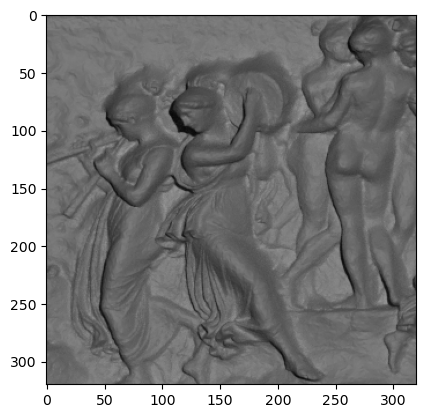

In [36]:
#Lambertian Photometric stereo example
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

#load all images of the stack and convert to grayscale
all_images = []
for fname in sorted(glob.glob(f"{"material4/"}/image*.png")):
    img = cv2.imread(fname,cv2.IMREAD_GRAYSCALE).flatten() 
    all_images.append(img.astype(np.float32) / 255.0)
    print 
    
img = cv2.imread(fname) 
plt.imshow(img)


(77, 3)
(102400, 3)


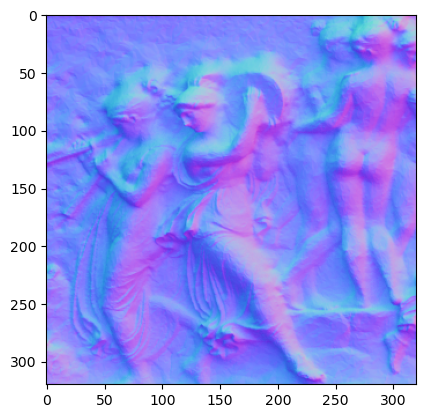

In [43]:
#load the light directions and normalize them

L = np.loadtxt("material4/light_directions.txt")
L = L / np.linalg.norm(L, ord=2, axis=1, keepdims=True)
print(L.shape)
images = np.stack(all_images)

#solve for the normals using least squares

normals=np.linalg.lstsq(L, images, rcond=None)[0].T
print(normals.shape)
magnitudes = np.linalg.norm(normals, axis=1, keepdims=True)
normals /= magnitudes

#encode normals as RGB and visualize them
normals = (normals + 1) / 2.0
normals = normals.reshape(img.shape)
plt.imshow(normals)

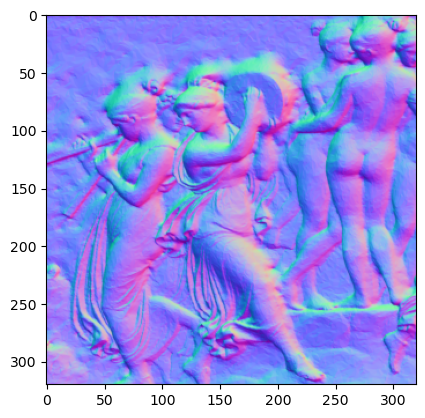

In [39]:
#load ground truth normals and visualize them
normalsGT = cv2.imread("material4/normals.png",cv2.IMREAD_COLOR_RGB)
plt.imshow(normalsGT)

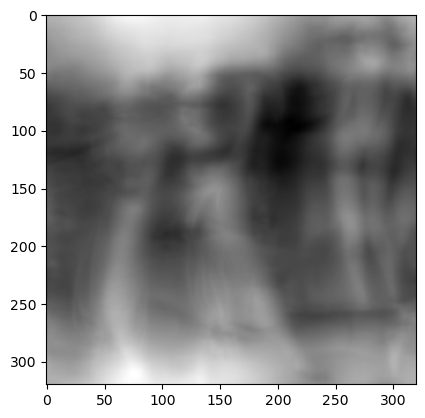

In [ ]:
#depth with normal integration using poisson solver

def integrate_normals_poisson(normals):
    nx = normals[:, :, 0]
    ny = normals[:, :, 1]
    nz = normals[:, :, 2]

    nz = np.where(np.abs(nz) < 1e-6, 1e-6, nz)

    p = -nx / nz  # dz/dx
    q = -ny / nz  # dz/dy

    h, w = p.shape

    # Derivatives of p and q
    px = np.zeros_like(p)
    qy = np.zeros_like(q)

    px[:, 1:] = p[:, 1:] - p[:, :-1]
    qy[1:, :] = q[1:, :] - q[:-1, :]

    f = px + qy

    # Fourier solve of Laplacian(z) = f
    F = np.fft.fft2(f)

    yy, xx = np.mgrid[0:h, 0:w]
    denom = (
        2 * np.cos(2 * np.pi * xx / w)
        + 2 * np.cos(2 * np.pi * yy / h)
        - 4
    ).astype(np.float32)

    denom[0, 0] = 1.0  # avoid division by zero
    Z = F / denom
    Z[0, 0] = 0.0      # fix arbitrary constant offset

    depth = np.real(np.fft.ifft2(Z))
    return depth


def normalize_depth(depth):
    dmin = depth.min()
    dmax = depth.max()
    if dmax - dmin < 1e-8:
        return np.zeros_like(depth)
    return (depth - dmin) / (dmax - dmin)




depth = integrate_normals_poisson(normals)
depth_vis = normalize_depth(depth)
plt.imshow(depth_vis, cmap="gray")

